## Analisi Dati - Business Report

dati: https://bit.ly/4teFc9H

In [1]:
import pandas as pd

Ho 4 file con:
* customerMD - paese di provenienza del cliente (chiave Customer_ID)
* productMD - dettaglio prodotto venduto con cat e subcat (Chiave Stock Code)
* transaction - file delle vendite + storico

D1: Quali sono i 10 prodotti più redditizi?


Importo le tabelle e creo dei dataframe

In [2]:
dfcu = pd.read_csv("T02-eCommerce-CustomerMD.csv", delimiter=";")
dfcu.head()

,Customer_ID,Country
0,12346,United Kingdom
1,12347,Iceland
2,12348,Finland
3,12349,Italy
4,12350,Norway


In [3]:
dfcu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5856 entries, 0 to 5855
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Customer_ID  5856 non-null   int64 
 1   Country      5856 non-null   object
dtypes: int64(1), object(1)
memory usage: 91.6+ KB


In [5]:
dfpr = pd.read_csv("T02-eCommerce-ProductMD.csv", delimiter=",", encoding="latin-1")
dfpr.head()

,StockCode,Description,Category,Subcategory
0,10002R,ROBOT PENCIL SHARPNER,Stationery,Desktop Stationery
1,10109,BENDY COLOUR PENCILS,Stationery,Desktop Stationery
2,10120,DOGGY RUBBER,Stationery,Desktop Stationery
3,10123C,HEARTS WRAPPING TAPE,Stationery,Desktop Stationery
4,10123G,ARMY CAMO WRAPPING TAPE,Stationery,Desktop Stationery


In [6]:
dfpr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3812 entries, 0 to 3811
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   StockCode    3812 non-null   object
 1   Description  3812 non-null   object
 2   Category     3812 non-null   object
 3   Subcategory  3812 non-null   object
dtypes: object(4)
memory usage: 119.3+ KB


In [7]:
dftr = pd.read_excel("T02-eCommerce-TransactionsL3M.xlsx", engine="openpyxl")
dftr.head()

/opt/anaconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Invoice,StockCode,Quantity,Price,Customer_ID,Invoice_time
0,565080,20677,8,1.25,13509,D01/9/19T08:25:00
1,565080,22128,24,1.25,13509,D01/9/19T08:25:00
2,565082,22423,2,12.75,13305,D01/9/19T09:15:00
3,565082,15060B,8,3.75,13305,D01/9/19T09:15:00
4,565082,23245,4,4.95,13305,D01/9/19T09:15:00


In [8]:
dftr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130287 entries, 0 to 130286
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Invoice       130287 non-null  object 
 1   StockCode     130287 non-null  object 
 2   Quantity      130287 non-null  int64  
 3   Price         130287 non-null  float64
 4   Customer_ID   130287 non-null  int64  
 5   Invoice_time  130287 non-null  object 
dtypes: float64(1), int64(2), object(3)
memory usage: 6.0+ MB


In [9]:
dftr.describe()

,Quantity,Price,Customer_ID
count,130287.000000,130287.000000,130287.000000
mean,11.546847,3.331089,15292.523045
std,52.140956,31.828257,1691.967447
min,-1296.000000,0.000000,12347.000000
25%,2.000000,1.250000,14044.000000
50%,4.000000,1.950000,15152.000000
75%,12.000000,3.750000,16748.000000
max,12540.000000,4161.060000,18287.000000


Come verificare che non ci siano dati nulli nelle colonne Qta e Price?


In [10]:
dftr[["Quantity", "Price"]].isna().sum()

Quantity    0
Price       0
dtype: int64

Se ci fossero dei nulli (NaN) e li voglio colmare farò:

In [11]:
dftr[["Quantity", "Price"]] = dftr[["Quantity", "Price"]].fillna(0)

In [12]:
dftrh = pd.read_excel("T02-eCommerce-TransactionsHistory.xlsx", engine="openpyxl")
dftrh.head()

/opt/anaconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Invoice,StockCode,Quantity,Price,Customer_ID,Invoice_time
0,489434,85048,12,6.95,13085,D01/12/17T07:45:00
1,489434,79323P,12,6.75,13085,D01/12/17T07:45:00
2,489434,79323W,12,6.75,13085,D01/12/17T07:45:00
3,489434,22041,48,2.10,13085,D01/12/17T07:45:00
4,489434,21232,24,1.25,13085,D01/12/17T07:45:00


In [13]:
dftrh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545592 entries, 0 to 545591
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Invoice       545592 non-null  object 
 1   StockCode     545592 non-null  object 
 2   Quantity      545592 non-null  int64  
 3   Price         545592 non-null  float64
 4   Customer_ID   545592 non-null  int64  
 5   Invoice_time  545592 non-null  object 
dtypes: float64(1), int64(2), object(3)
memory usage: 25.0+ MB


unisco i due dataframe delle transazioni

In [15]:
df_tot = pd.concat([dftr, dftrh], ignore_index=True, sort=False)
df_tot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 675879 entries, 0 to 675878
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Invoice       675879 non-null  object 
 1   StockCode     675879 non-null  object 
 2   Quantity      675879 non-null  int64  
 3   Price         675879 non-null  float64
 4   Customer_ID   675879 non-null  int64  
 5   Invoice_time  675879 non-null  object 
dtypes: float64(1), int64(2), object(3)
memory usage: 30.9+ MB


In [16]:
df_tot.head()

,Invoice,StockCode,Quantity,Price,Customer_ID,Invoice_time
0,565080,20677,8,1.25,13509,D01/9/19T08:25:00
1,565080,22128,24,1.25,13509,D01/9/19T08:25:00
2,565082,22423,2,12.75,13305,D01/9/19T09:15:00
3,565082,15060B,8,3.75,13305,D01/9/19T09:15:00
4,565082,23245,4,4.95,13305,D01/9/19T09:15:00


In [17]:
customer = dfcu
product = dfpr
transactions = df_tot

transactions2 = transactions.merge(customer, on="Customer_ID", how='left')
transactions2.head()

,Invoice,StockCode,Quantity,Price,Customer_ID,Invoice_time,Country
0,565080,20677,8,1.25,13509,D01/9/19T08:25:00,United Kingdom
1,565080,22128,24,1.25,13509,D01/9/19T08:25:00,United Kingdom
2,565082,22423,2,12.75,13305,D01/9/19T09:15:00,United Kingdom
3,565082,15060B,8,3.75,13305,D01/9/19T09:15:00,United Kingdom
4,565082,23245,4,4.95,13305,D01/9/19T09:15:00,United Kingdom


In [18]:
transactions3 = transactions2.merge(product, on="StockCode", how='left')
transactions3.head()

,Invoice,StockCode,Quantity,Price,Customer_ID,Invoice_time,Country,Description,Category,Subcategory
0,565080,20677,8,1.25,13509,D01/9/19T08:25:00,United Kingdom,PINK POLKADOT BOWL,Home,Furniture
1,565080,22128,24,1.25,13509,D01/9/19T08:25:00,United Kingdom,PARTY CONES CANDY ASSORTED,Kids,Party
2,565082,22423,2,12.75,13305,D01/9/19T09:15:00,United Kingdom,REGENCY CAKESTAND 3 TIER,Home,Kitchen
3,565082,15060B,8,3.75,13305,D01/9/19T09:15:00,United Kingdom,FAIRY CAKE DESIGN UMBRELLA,Seasonal,Summer
4,565082,23245,4,4.95,13305,D01/9/19T09:15:00,United Kingdom,SET OF 3 REGENCY CAKE TINS,Home,Kitchen


Per trovare quali sono i 10 prodotti più redditizi:

* calcolare il valore venduto per riga
* raggruppare per prodotto
* sommare

In [19]:
transactions3["total_row"] = transactions3["Quantity"] * transactions3["Price"]
transactions3.head(5)

,Invoice,StockCode,Quantity,Price,Customer_ID,Invoice_time,Country,Description,Category,Subcategory,total_row
0,565080,20677,8,1.25,13509,D01/9/19T08:25:00,United Kingdom,PINK POLKADOT BOWL,Home,Furniture,10.0
1,565080,22128,24,1.25,13509,D01/9/19T08:25:00,United Kingdom,PARTY CONES CANDY ASSORTED,Kids,Party,30.0
2,565082,22423,2,12.75,13305,D01/9/19T09:15:00,United Kingdom,REGENCY CAKESTAND 3 TIER,Home,Kitchen,25.5
3,565082,15060B,8,3.75,13305,D01/9/19T09:15:00,United Kingdom,FAIRY CAKE DESIGN UMBRELLA,Seasonal,Summer,30.0
4,565082,23245,4,4.95,13305,D01/9/19T09:15:00,United Kingdom,SET OF 3 REGENCY CAKE TINS,Home,Kitchen,19.8


In [26]:
tot_prodotto = (transactions3.groupby("Description")["total_row"].sum().reset_index())
tot_prodotto.head()

,Description,total_row
0,50'S CHRISTMAS GIFT BAG LARGE,2232.250
1,Bank Charges,330.001
2,DOLLY GIRL BEAKER,2658.250
3,HOME SWEET HOME BLACKBOARD,696.910
4,RED SPOT GIFT BAG LARGE,2059.750


In [31]:
tp1 = tot_prodotto.sort_values(by="total_row", ascending=False)
report1 = tp1.head(10)
report1.reset_index(drop=True, inplace=True)
report1

,Description,total_row
0,REGENCY CAKESTAND 3 TIER,265295.62
1,WHITE HANGING HEART T-LIGHT HOLDER,240707.67
2,JUMBO BAG RED RETROSPOT,166451.16
3,ASSORTED COLOUR BIRD ORNAMENT,124354.72
4,POSTAGE,109511.60
5,PARTY BUNTING,102220.93
6,PAPER CHAIN KIT 50'S CHRISTMAS,74510.46
7,CHILLI LIGHTS,70118.67
8,JUMBO BAG PINK POLKADOT,66771.74
9,DOORMAT UNION FLAG,64128.57


In [33]:
#rinomino le colonne
report2 = report1.rename(columns={"Description":"prodotto", "total_row":"totale"})
report2

,prodotto,totale
0,REGENCY CAKESTAND 3 TIER,265295.62
1,WHITE HANGING HEART T-LIGHT HOLDER,240707.67
2,JUMBO BAG RED RETROSPOT,166451.16
3,ASSORTED COLOUR BIRD ORNAMENT,124354.72
4,POSTAGE,109511.60
5,PARTY BUNTING,102220.93
6,PAPER CHAIN KIT 50'S CHRISTMAS,74510.46
7,CHILLI LIGHTS,70118.67
8,JUMBO BAG PINK POLKADOT,66771.74
9,DOORMAT UNION FLAG,64128.57


In [35]:
import matplotlib.pyplot as plt


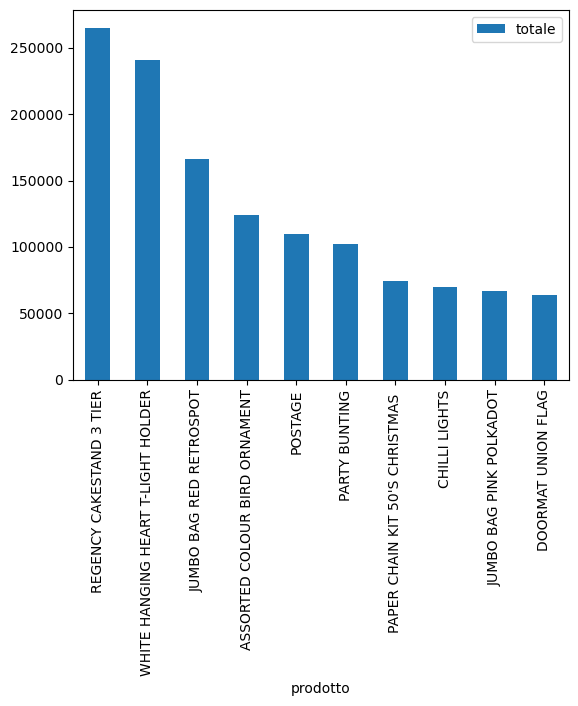

In [36]:
report2.plot(x="prodotto", y="totale", kind="bar")
plt.show()

## Trovare le 10 categorie che vendono di più


In [37]:
customer = dfcu
product = dfpr
transactions = df_tot

In [38]:
customer.head(3)

,Customer_ID,Country
0,12346,United Kingdom
1,12347,Iceland
2,12348,Finland


In [39]:
product.head(3)

,StockCode,Description,Category,Subcategory
0,10002R,ROBOT PENCIL SHARPNER,Stationery,Desktop Stationery
1,10109,BENDY COLOUR PENCILS,Stationery,Desktop Stationery
2,10120,DOGGY RUBBER,Stationery,Desktop Stationery


In [40]:
transactions.head(3)

,Invoice,StockCode,Quantity,Price,Customer_ID,Invoice_time
0,565080,20677,8,1.25,13509,D01/9/19T08:25:00
1,565080,22128,24,1.25,13509,D01/9/19T08:25:00
2,565082,22423,2,12.75,13305,D01/9/19T09:15:00


In [41]:
#aggiungo alla tabella transactions una colonna con il venduto 
#per singolo prodotto. Il venduto è pari a Quantity * Price
transactions["total_row"] = transactions["Quantity"]*transactions["Price"]
transactions.head(3) 

,Invoice,StockCode,Quantity,Price,Customer_ID,Invoice_time,total_row
0,565080,20677,8,1.25,13509,D01/9/19T08:25:00,10.0
1,565080,22128,24,1.25,13509,D01/9/19T08:25:00,30.0
2,565082,22423,2,12.75,13305,D01/9/19T09:15:00,25.5


In [42]:
# collego la tabella prodotto alle transaction così da avere su ogni riga
# la categoria e la sottocategoria
df2 = transactions.merge(product, on="StockCode", how="left")
df2.head(3)

,Invoice,StockCode,Quantity,Price,Customer_ID,Invoice_time,total_row,Description,Category,Subcategory
0,565080,20677,8,1.25,13509,D01/9/19T08:25:00,10.0,PINK POLKADOT BOWL,Home,Furniture
1,565080,22128,24,1.25,13509,D01/9/19T08:25:00,30.0,PARTY CONES CANDY ASSORTED,Kids,Party
2,565082,22423,2,12.75,13305,D01/9/19T09:15:00,25.5,REGENCY CAKESTAND 3 TIER,Home,Kitchen


In [44]:
#ora raggruppo per categoria e sommo su total_row
df3 = (df2.groupby("Category")["total_row"].sum().reset_index())
df3.head(10)

,Category,total_row
0,Accessories,2028866.050
1,Air fragances,1222760.050
2,Hobbies,775861.560
3,Home,6718972.087
4,Kids,987284.330
5,Others,-69056.689
6,Seasonal,984499.920
7,Stationery,1367954.940


In [46]:
#ordino le righe per totale desc
df4 = df3.sort_values(by="total_row", ascending=False)
df4.head(10)


,Category,total_row
3,Home,6718972.087
0,Accessories,2028866.050
7,Stationery,1367954.940
1,Air fragances,1222760.050
4,Kids,987284.330
6,Seasonal,984499.920
2,Hobbies,775861.560
5,Others,-69056.689
